<h1>01 · EDA Pipeline — aplicado a dataset Bank Customer <a id="inicio"> </h1>
<em>Notebook desarrollado por Evelyn Cabrera Arias.</em><br><br>

<b>Repositorio:</b> <code>credit-risk-score</code><br>
<b>Dataset:</b> <code>dataset_bank_customer.csv</code><br>
<b>Registros:</b> 10,000 &nbsp;·&nbsp; <b>Variables:</b> 16<br>
<b>Objetivo:</b> Diagnosticar calidad de datos, explorar distribuciones y preparar el dataset para el modelo de scoring crediticio.

<hr>

<h3 style="color: #0d47a1;">Estructura del pipeline:</h3>

<a href="#seccion-1"  style="color:black; text-decoration:underline; display:block; margin:3px 0; font-size:15px;">1. Carga de datos</a>
<a href="#seccion-2"  style="color:black; text-decoration:underline; display:block; margin:3px 0; font-size:15px;">2. Revisión estructural</a>
<a href="#seccion-3"  style="color:black; text-decoration:underline; display:block; margin:3px 0; font-size:15px;">3. Análisis de valores nulos</a>
<a href="#seccion-4"  style="color:black; text-decoration:underline; display:block; margin:3px 0; font-size:15px;">4. Variable objetivo — 'moroso'</a>
<a href="#seccion-5"  style="color:black; text-decoration:underline; display:block; margin:3px 0; font-size:15px;">5. Distribuciones — variables numéricas</a>
<a href="#seccion-6"  style="color:black; text-decoration:underline; display:block; margin:3px 0; font-size:15px;">6. Variables categóricas</a> 
<a href="#seccion-7"  style="color:black; text-decoration:underline; display:block; margin:3px 0; font-size:15px;">7. Correlación con variable objetivo</a>
<a href="#seccion-8"  style="color:black; text-decoration:underline; display:block; margin:3px 0; font-size:15px;">8. Boxplots: morosos vs no morosos</a>
<a href="#seccion-9"  style="color:black; text-decoration:underline; display:block; margin:3px 0; font-size:15px;">9. Hallazgos y próximos pasos</a>

## 1. Carga de datos <a id="seccion-1"></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid', palette='muted')
pd.set_option('display.float_format', '{:.2f}'.format)

df = pd.read_csv('../data/raw/dataset_bank_customer.csv', sep=';')
print(f"Shape: {df.shape}")
df.head()

Shape: (10000, 16)


,id_cliente,score_originacion,pais,sexo,edad,tenencia,saldo_promedio,numero_productos,tarjeta_credito,miembro_activo,ingresos_mensuales,fecha_apertura,estado_civil,segmento_cliente,deuda_total,moroso
0,15634602,619,France,Female,42,2,0.00,1,1,1,101348.88,8/12/2010,Soltero,C,0.00,1
1,15647311,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,1/07/2016,Soltero,C,167615.72,0
2,15619304,502,France,Female,42,8,159660.80,3,1,0,113931.57,3/02/2016,Divorciado,D,319321.60,1
3,15701354,699,France,Female,39,1,0.00,2,0,0,93826.63,23/04/2018,Soltero,B,0.00,0
4,15737888,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,18/02/2012,Soltero,A,251021.64,0


## 2. Revisión estructural <a id="seccion-2"></a>

In [2]:
# Tipos de datos y primeras observaciones
print("=== Info ===")
df.info()
print("\n=== Duplicados:", df.duplicated().sum(), "===")
print("\n=== Columnas:", list(df.columns))

=== Info ===
<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 16 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   id_cliente          10000 non-null  int64  
 1   score_originacion   10000 non-null  int64  
 2   pais                10000 non-null  str    
 3   sexo                10000 non-null  str    
 4   edad                10000 non-null  int64  
 5   tenencia            10000 non-null  int64  
 6   saldo_promedio      10000 non-null  float64
 7   numero_productos    10000 non-null  int64  
 8   tarjeta_credito     10000 non-null  int64  
 9   miembro_activo      10000 non-null  int64  
 10  ingresos_mensuales  10000 non-null  float64
 11  fecha_apertura      10000 non-null  str    
 12  estado_civil        10000 non-null  str    
 13  segmento_cliente    10000 non-null  str    
 14  deuda_total         10000 non-null  float64
 15  moroso              10000 non-null  int64  
dtypes: 

In [3]:
# Estadísticas descriptivas
fmt = {
    "count": "{:,.0f}",
    "mean":  "{:,.2f}",
    "std":   "{:,.2f}",
    "min":   "{:,.2f}",
    "25%":   "{:,.2f}",
    "50%":   "{:,.2f}",
    "75%":   "{:,.2f}",
    "max":   "{:,.2f}",
}

df.describe().T.style\
    .background_gradient(cmap='Blues')\
    .format(fmt)
#df.describe().T.style.background_gradient(cmap='Blues')

,count,mean,std,min,25%,50%,75%,max
id_cliente,"10,000","15,690,940.57","71,936.19","15,565,701.00","15,628,528.25","15,690,738.00","15,753,233.75","15,815,690.00"
score_originacion,"10,000",650.53,96.65,350.00,584.00,652.00,718.00,850.00
edad,"10,000",38.92,10.49,18.00,32.00,37.00,44.00,92.00
tenencia,"10,000",5.01,2.89,0.00,3.00,5.00,7.00,10.00
saldo_promedio,"10,000","76,485.89","62,397.41",0.00,0.00,"97,198.54","127,644.24","250,898.09"
numero_productos,"10,000",1.53,0.58,1.00,1.00,1.00,2.00,4.00
tarjeta_credito,"10,000",0.71,0.46,0.00,0.00,1.00,1.00,1.00
miembro_activo,"10,000",0.52,0.50,0.00,0.00,1.00,1.00,1.00
ingresos_mensuales,"10,000","100,090.24","57,510.49",11.58,"51,002.11","100,193.91","149,388.25","199,992.48"
deuda_total,"10,000","152,971.78","124,794.81",0.00,0.00,"194,397.08","255,288.48","501,796.18"


## 3. Análisis de valores nulos <a id="seccion-3"></a>

In [4]:
nulls = df.isnull().sum()
pct   = (nulls / len(df) * 100).round(2)
missing = pd.DataFrame({'nulos': nulls, 'porcentaje': pct})
missing[missing['nulos'] > 0]

,nulos,porcentaje


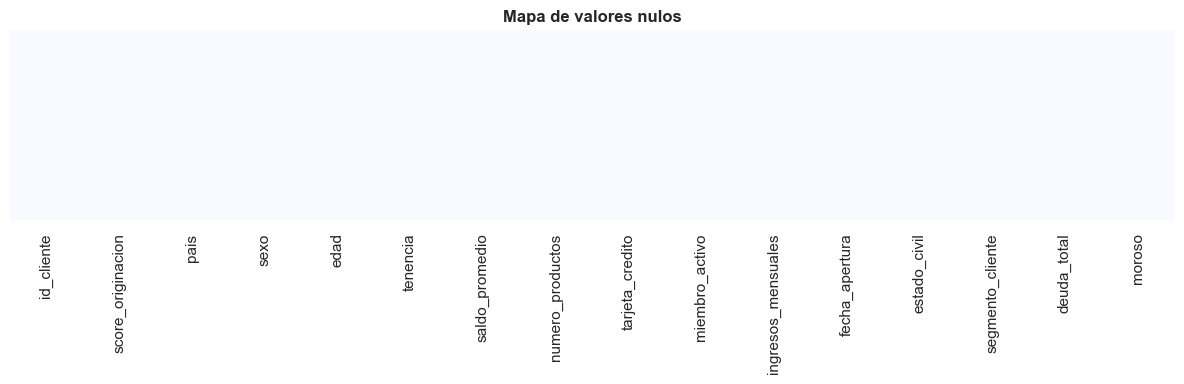

In [5]:
# Heatmap de nulos
plt.figure(figsize=(12, 4))
sns.heatmap(df.isnull(), cbar=False, yticklabels=False, cmap='Blues')
plt.title('Mapa de valores nulos', fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/plots/01_missing_heatmap.png', dpi=150)
plt.show()

En este caso la data no tenía nulos, pero tengo otro proyecto donde puedes visualizar este mapeo:
<em><a href=https://github.com/evelyncabrera-pe/eda-pipeline/blob/main/notebooks/eda_pipeline.ipynb style="color:black; text-decoration:underline; display:block; margin:3px 0; font-size:15px;">(repositorio eda_pipeline)</a></em>

## 4. Variable objetivo — 'moroso' <a id="seccion-4"></a>

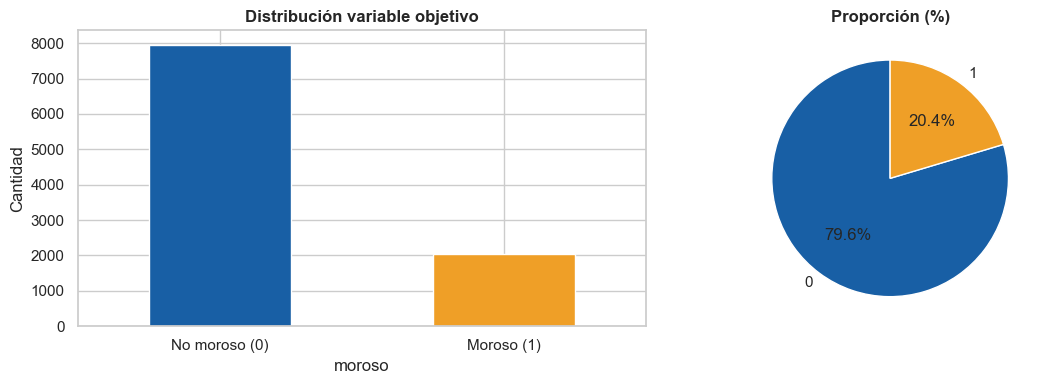

Tasa de mora: 20.4%


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Distribución
df['moroso'].value_counts().plot(kind='bar', ax=axes[0], color=['#185FA5', '#EF9F27'], edgecolor='white')
axes[0].set_title('Distribución variable objetivo', fontweight='bold')
axes[0].set_xticklabels(['No moroso (0)', 'Moroso (1)'], rotation=0)
axes[0].set_ylabel('Cantidad')

# Proporción
df['moroso'].value_counts(normalize=True).mul(100).plot(kind='pie', ax=axes[1],
    autopct='%1.1f%%', colors=['#185FA5', '#EF9F27'], startangle=90)
axes[1].set_title('Proporción (%)', fontweight='bold')
axes[1].set_ylabel('')

plt.tight_layout()
plt.savefig('../outputs/plots/01_target_distribution.png', dpi=150)
plt.show()
print(f"Tasa de mora: {df['moroso'].mean()*100:.1f}%")

## 5. Distribuciones — variables numéricas <a id="seccion-5"></a>

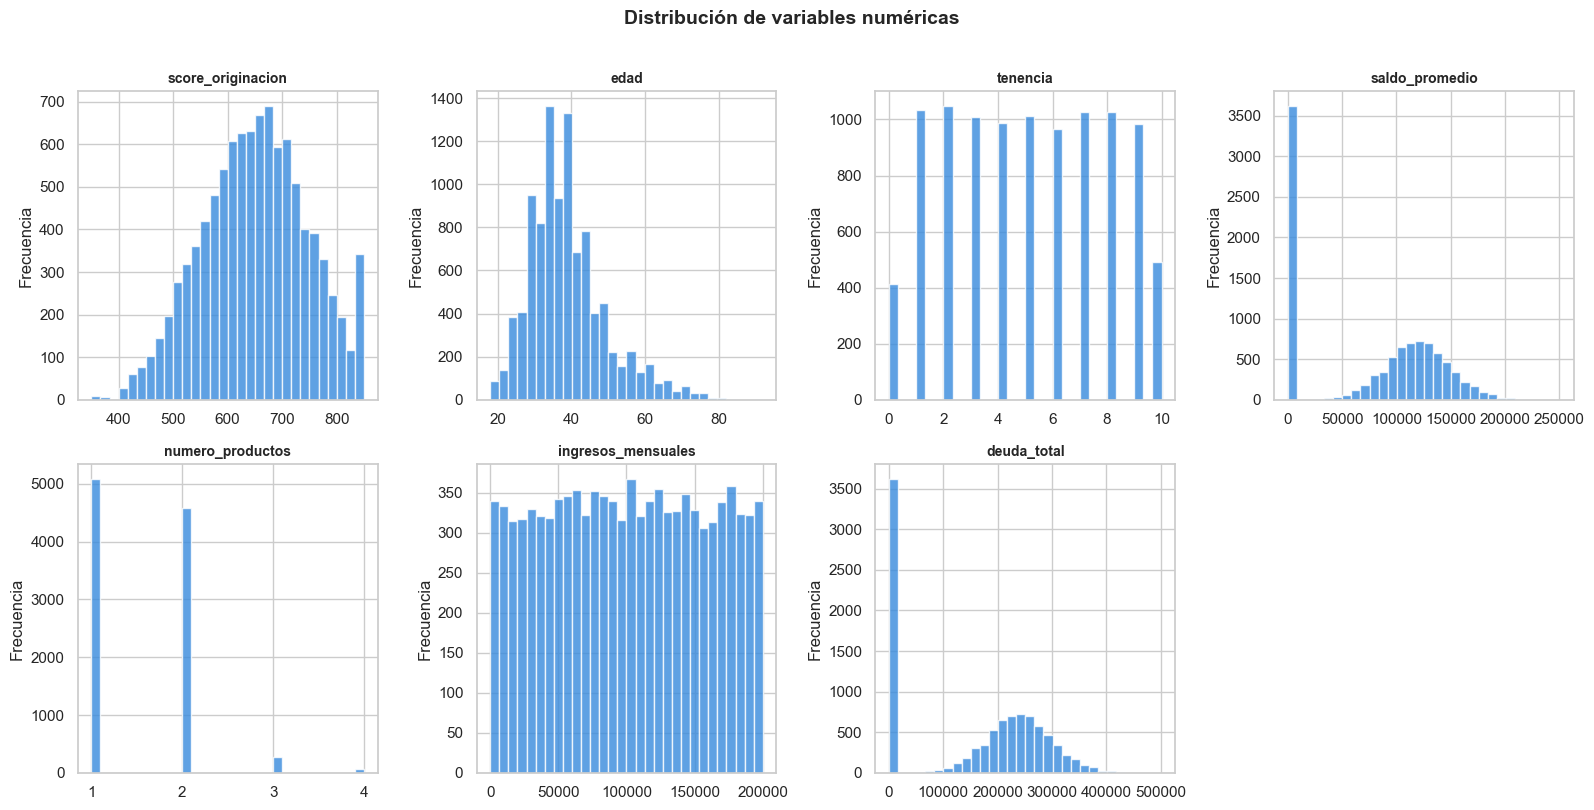

In [7]:
num_cols = ['score_originacion','edad','tenencia','saldo_promedio',
            'numero_productos','ingresos_mensuales','deuda_total']

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    axes[i].hist(df[col], bins=30, color='#378ADD', edgecolor='white', alpha=0.8)
    axes[i].set_title(col, fontweight='bold', fontsize=10)
    axes[i].set_ylabel('Frecuencia')

axes[-1].set_visible(False)
plt.suptitle('Distribución de variables numéricas', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../outputs/plots/01_numeric_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Variables categóricas <a id="seccion-6"></a>

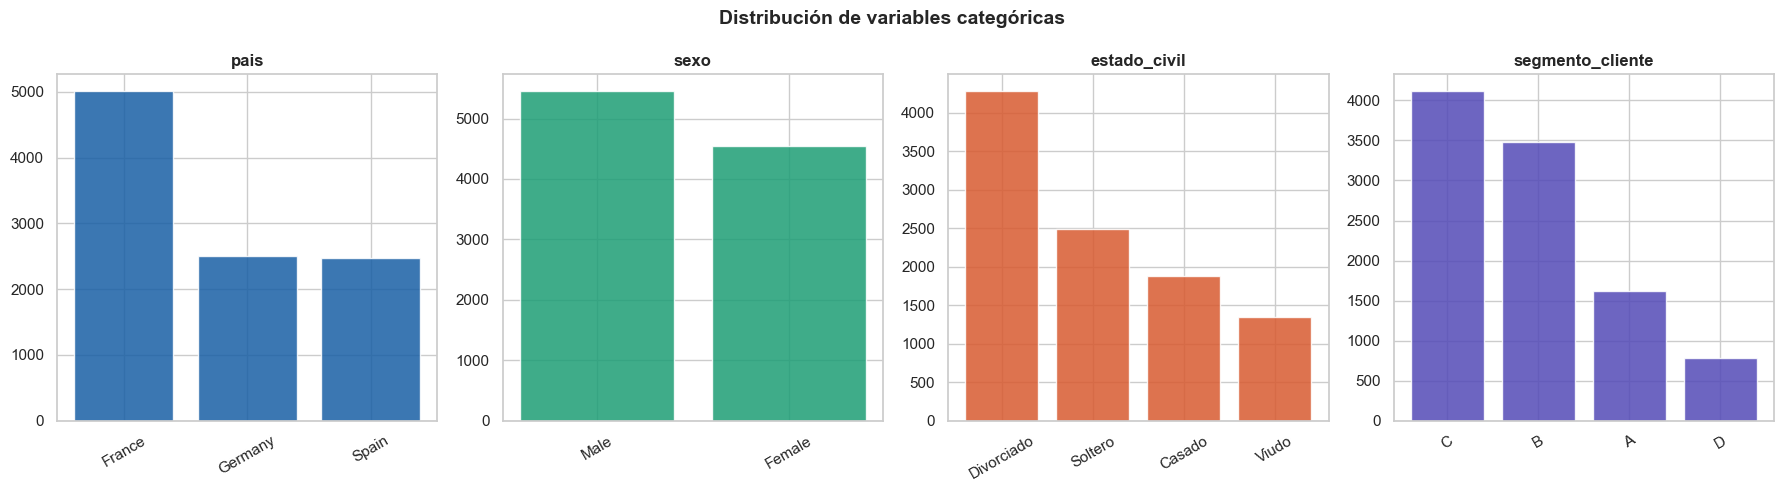

In [8]:
cat_cols = ['pais', 'sexo', 'estado_civil', 'segmento_cliente']
colors   = ['#185FA5','#1D9E75','#D85A30','#534AB7']

fig, axes = plt.subplots(1, 4, figsize=(18, 5))
for ax, col, color in zip(axes, cat_cols, colors):
    vc = df[col].value_counts()
    ax.bar(vc.index, vc.values, color=color, edgecolor='white', alpha=0.85)
    ax.set_title(col, fontweight='bold')
    ax.tick_params(axis='x', rotation=30)

plt.suptitle('Distribución de variables categóricas', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/plots/01_categorical_distributions.png', dpi=150)
plt.show()

## 7. Correlación con variable objetivo <a id="seccion-7"></a>

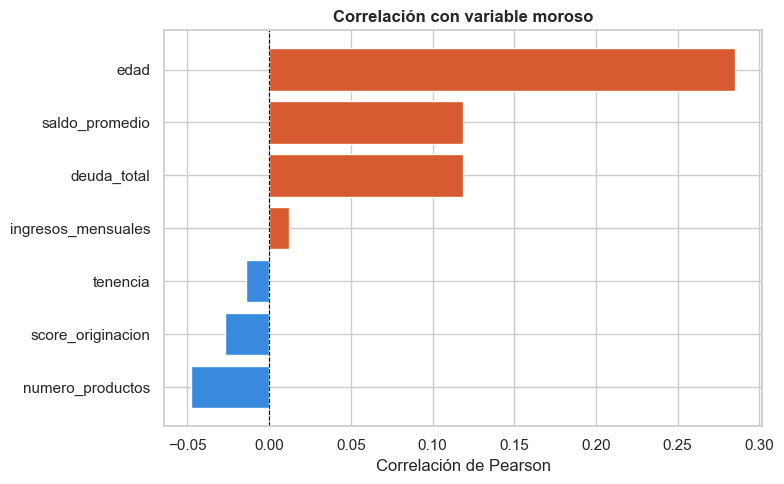

In [9]:
num_df = df[num_cols + ['moroso']].copy()
corr   = num_df.corr()[['moroso']].drop('moroso').sort_values('moroso')

plt.figure(figsize=(8, 5))
colors_bar = ['#D85A30' if v > 0 else '#378ADD' for v in corr['moroso']]
plt.barh(corr.index, corr['moroso'], color=colors_bar, edgecolor='white')
plt.axvline(0, color='black', linewidth=0.8, linestyle='--')
plt.title('Correlación con variable moroso', fontweight='bold')
plt.xlabel('Correlación de Pearson')
plt.tight_layout()
plt.savefig('../outputs/plots/01_correlation_target.png', dpi=150)
plt.show()

## 8. Boxplots: morosos vs no morosos <a id="seccion-8"></a>

In [10]:
print(df['moroso'].dtype)       # int64, object, etc.
print(df['moroso'].unique())    # te muestra los valores reales

int64
[1 0]


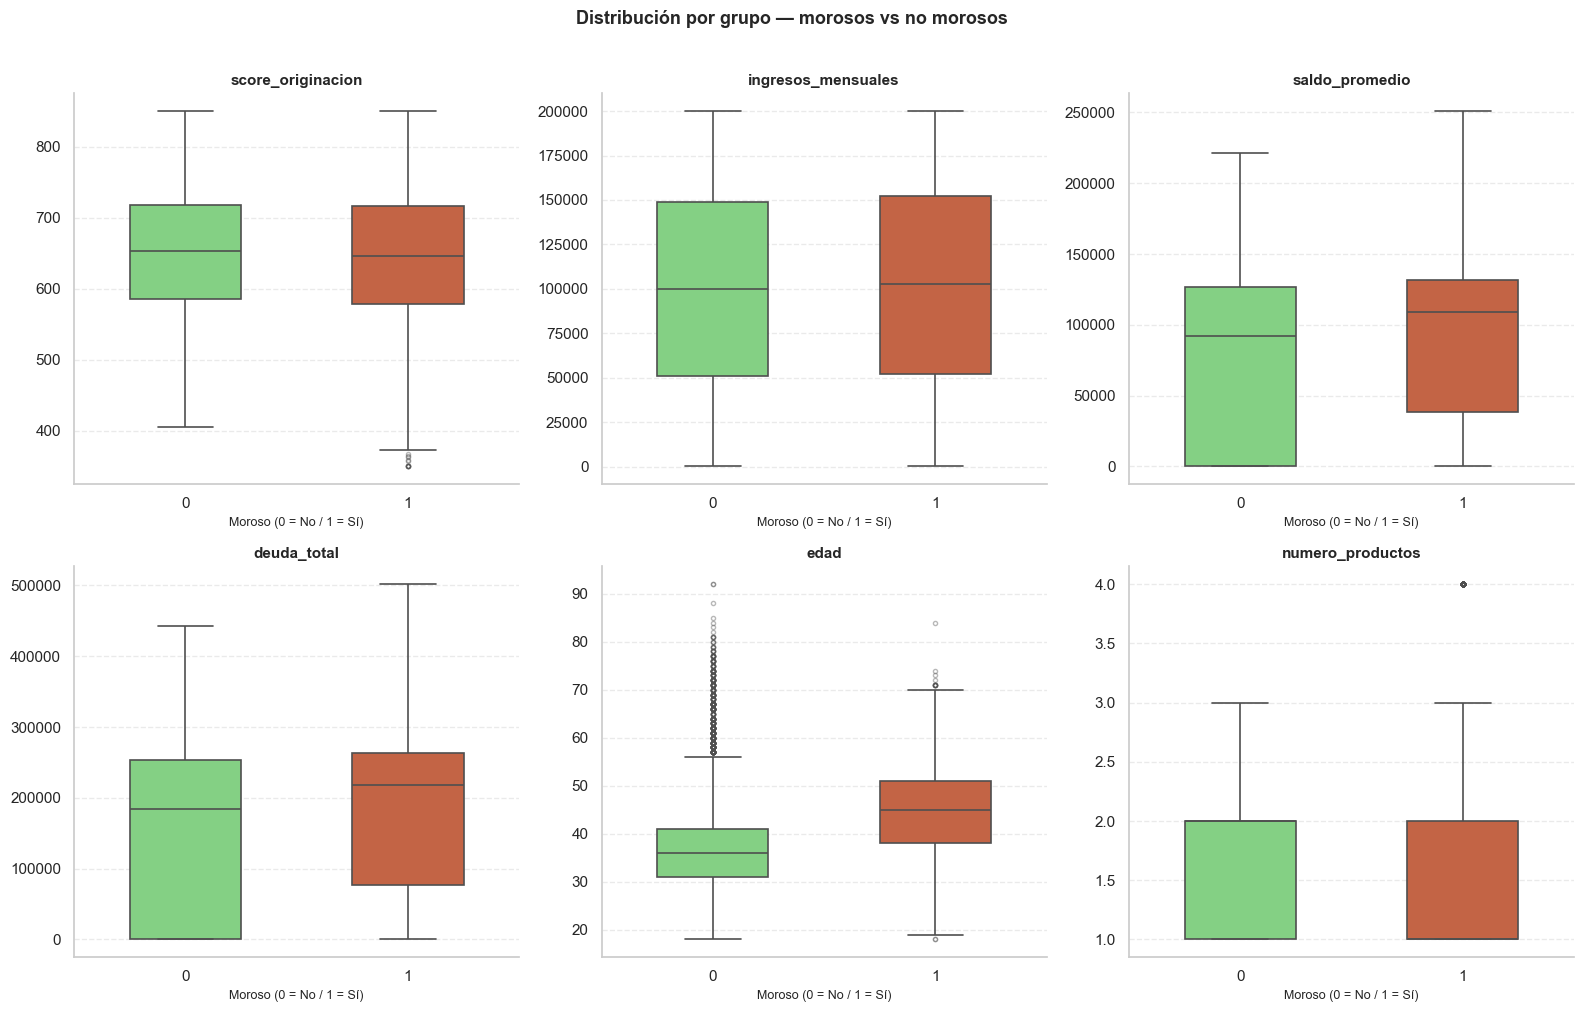

In [11]:
import seaborn as sns

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

key_vars = ['score_originacion', 'ingresos_mensuales', 'saldo_promedio',
            'deuda_total', 'edad', 'numero_productos']

palette = {0: '#77DD77', 1: '#D85A30'}   # verde = no moroso, coral = moroso

for ax, var in zip(axes, key_vars):
    sns.boxplot(
        data=df,
        x='moroso',
        y=var,
        ax=ax,
        hue='moroso',        
        palette=palette,
        legend=False,        
        width=0.5,
        linewidth=1.2,
        flierprops=dict(marker='o', markersize=3, alpha=0.4),  # outliers más sutiles
    )
    ax.set_title(var, fontweight='bold', fontsize=11)
    ax.set_xlabel('Moroso (0 = No / 1 = Sí)', fontsize=9)
    ax.set_ylabel('')
    ax.grid(axis='y', linestyle='--', alpha=0.4)   # grilla horizontal suave
    sns.despine(ax=ax)                              # elimina bordes superior y derecho

plt.suptitle('Distribución por grupo — morosos vs no morosos',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../outputs/plots/01_boxplots_by_target.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Hallazgos y próximos pasos <a id="seccion-9"></a>

In [12]:
print("====== RESUMEN EDA ======")
print(f"Registros: {len(df):,}")
print(f"Variables: {df.shape[1]}")
print(f"Nulos: {df.isnull().sum().sum()}")
print(f"Tasa de mora: {df['moroso'].mean()*100:.1f}%")
print(f"Dataset desbalanceado: {df['moroso'].value_counts()[0]:,} no morosos vs {df['moroso'].value_counts()[1]:,} morosos")
print()
print("Variables con mayor señal hacia moroso:")
print(corr.sort_values('moroso', ascending=False).to_string())

====== RESUMEN EDA ======
Registros: 10,000
Variables: 16
Nulos: 0
Tasa de mora: 20.4%
Dataset desbalanceado: 7,963 no morosos vs 2,037 morosos

Variables con mayor señal hacia moroso:
                    moroso
edad                  0.29
deuda_total           0.12
saldo_promedio        0.12
ingresos_mensuales    0.01
tenencia             -0.01
score_originacion    -0.03
numero_productos     -0.05


<h3 style="color: #0d47a1;">Hallazgos clave:</h3>

- Dataset completo: sin valores nulos
- Desbalance de clases: ~20% morosos vs ~80% no morosos → se usará `class_weight='balanced'`
- `score_originacion` es la variable con mayor correlación con morosidad
- `saldo_promedio` y `deuda_total` muestran diferencias claras entre grupos
- Variables categóricas (`segmento_cliente`, `pais`) requieren encoding

<h3 style="color: #0d47a1;">Siguiente paso: </h3>
`02_exploracion.ipynb` — ingeniería de features y preparación completa 
<em><a href="#inicio"  style="color:black; text-decoration:underline; display:block; margin:3px 0; font-size:15px;">Volver a inicio del eda-pipeline</a></em>